#Group 3 – Phase 3: Data Pre-processing & EDA

Dataset: Diabetes Risk Prediction Dataset (Kaggle)

Group members: Jumanah Ibrahim, Arwa Almutairi, Dana Alturki, Shatha Munif


## Introduction
In this phase, we focus on preparing the dataset and exploring it using EDA. The goal is to understand the data better

## 1) Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2) Data Loading

In [26]:
df = pd.read_csv("/diabetes_risk_dataset.csv")
#show 5 first rows
df.head()
#https://www.kaggle.com/datasets/vishardmehta/diabetes-risk-prediction-dataset DB link

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


The dataset was loaded successfully, and we displayed the first few rows to get an initial understanding of the data and its features.

# 3) data Inspection

###a) Dataset structure

In [27]:
# Shape: (rows, columns)
df.shape

(6000, 19)

In [28]:
# Column names
df.columns

Index(['Patient_ID', 'age', 'gender', 'bmi', 'blood_pressure',
       'fasting_glucose_level', 'insulin_level', 'HbA1c_level',
       'cholesterol_level', 'triglycerides_level', 'physical_activity_level',
       'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours',
       'stress_level', 'family_history_diabetes', 'waist_circumference_cm',
       'diabetes_risk_score', 'diabetes_risk_category'],
      dtype='object')

### Dataset Structure
The dataset contains 6000 rows and 19 columns, which indicates that it is large enough for analysis and machine learning tasks. The features include various health and lifestyle indicators such as age, BMI, glucose level, and blood pressure, which are relevant for predicting diabetes risk.

###b) data types

In [29]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  6000 non-null   int64  
 1   age                         6000 non-null   int64  
 2   gender                      6000 non-null   object 
 3   bmi                         6000 non-null   float64
 4   blood_pressure              6000 non-null   int64  
 5   fasting_glucose_level       6000 non-null   int64  
 6   insulin_level               6000 non-null   float64
 7   HbA1c_level                 6000 non-null   float64
 8   cholesterol_level           6000 non-null   int64  
 9   triglycerides_level         6000 non-null   int64  
 10  physical_activity_level     6000 non-null   object 
 11  daily_calorie_intake        6000 non-null   int64  
 12  sugar_intake_grams_per_day  6000 non-null   float64
 13  sleep_hours                 6000 

### Data Types
From the dataset information, we can see that all columns have 6000 non-null values, which means there are no missing values in the dataset.

The dataset includes different types of features:
- Numerical features such as age, BMI, glucose level, and blood pressure.
- Categorical features such as gender, physical activity level, and diabetes risk category.

Understanding these data types is important because numerical features may require scaling, while categorical features need to be encoded before applying machine learning models.

###c) summary statistics

In [30]:
# Summary statistics for numeric columns
df.describe()

,Patient_ID,age,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,diabetes_risk_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,52.230667,32.939667,144.482500,106.105500,15.080333,5.784583,217.490667,177.351500,2479.547000,66.555733,6.998700,5.086500,105.049600,48.691417
std,1732.195139,18.757508,7.510155,17.867248,31.213994,9.245581,0.956614,24.888595,51.897606,548.410642,39.576891,1.331378,2.342989,25.079335,37.242034
min,1.000000,20.000000,16.000000,91.000000,60.000000,2.000000,4.100000,139.000000,50.000000,1200.000000,0.000000,4.000000,1.000000,60.000000,0.000000
25%,1500.750000,36.000000,26.900000,132.000000,87.000000,7.100000,5.200000,200.000000,137.000000,2055.000000,35.100000,6.100000,3.000000,84.700000,12.900000
50%,3000.500000,53.000000,32.750000,144.000000,96.000000,13.800000,5.500000,217.000000,173.000000,2385.000000,58.300000,7.100000,5.000000,104.600000,43.900000
75%,4500.250000,68.000000,38.500000,157.000000,114.000000,21.000000,6.100000,234.000000,213.000000,2848.250000,89.300000,8.000000,7.000000,124.200000,88.800000
max,6000.000000,84.000000,50.000000,200.000000,281.000000,55.900000,11.000000,309.000000,383.000000,5249.000000,255.000000,10.000000,10.000000,150.000000,100.000000


### Summary Statistics
From the summary statistics, we can observe general information about the numerical features in the dataset.

The average age is around 52 years, which indicates that most individuals in the dataset are middle-aged. The average BMI is around 33, which falls in the overweight range, suggesting that many individuals may have a higher risk of diabetes.

The average fasting glucose level is approximately 106, which is slightly above the normal range, indicating potential risk among many individuals. Additionally, the HbA1c level has an average of around 5.78, which is close to the prediabetes threshold.

We can also see variation in features such as cholesterol, triglycerides, and daily calorie intake, which suggests differences in lifestyle and health conditions among individuals.

Overall, these statistics provide an initial understanding of the dataset and highlight important features that may influence diabetes risk prediction.

# 4) data cleaning

### a) ckeck for missing values

In [31]:
# Check for missing values in each column
df.isnull().sum().sort_values(ascending=False)
# no missing values

,0
Patient_ID,0
age,0
gender,0
bmi,0
blood_pressure,0
fasting_glucose_level,0
insulin_level,0
HbA1c_level,0
cholesterol_level,0
triglycerides_level,0


### Missing Values
We checked for missing values and found that all columns have complete data with no missing values. This means the dataset is clean and ready for the next steps.

### b) check for duplicated data

In [32]:
df.duplicated().sum()
#to show duplicated rows
#no duplicated data

np.int64(0)

### Duplicated Data
We checked for duplicate records in the dataset and found that there are no duplicated rows. This indicates that the data is consistent and does not require removal of duplicates.

## c) data encoding

In [33]:
df.columns

Index(['Patient_ID', 'age', 'gender', 'bmi', 'blood_pressure',
       'fasting_glucose_level', 'insulin_level', 'HbA1c_level',
       'cholesterol_level', 'triglycerides_level', 'physical_activity_level',
       'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours',
       'stress_level', 'family_history_diabetes', 'waist_circumference_cm',
       'diabetes_risk_score', 'diabetes_risk_category'],
      dtype='object')

In [34]:
#df = pd.get_dummies(df, columns=['gender','physical_activity_level','family_history_diabetes','diabetes_risk_category'])


### Data Encoding
We reviewed the categorical features in the dataset, such as gender, physical activity level, family history of diabetes, and diabetes risk category. These features are already represented in a usable format, so no additional encoding was required at this stage.


data is already encoded

## d)check for data types

In [35]:
df.dtypes

,0
Patient_ID,int64
age,int64
gender,object
bmi,float64
blood_pressure,int64
fasting_glucose_level,int64
insulin_level,float64
HbA1c_level,float64
cholesterol_level,int64
triglycerides_level,int64


### Data Types Verification
We examined the data types of all columns to ensure they are appropriate for analysis.

The dataset includes numerical features such as age, BMI, blood pressure, and glucose levels, which are stored as integers or floats. It also includes categorical features such as gender, physical activity level, family history of diabetes, and diabetes risk category, which are stored as object types.

Overall, the data types are correctly assigned, and the dataset is well-prepared for further analysis and modeling.

In [36]:
df['Patient_ID'] = df['Patient_ID'].astype(str)
# convert ID to string

In [37]:
df.dtypes

,0
Patient_ID,object
age,int64
gender,object
bmi,float64
blood_pressure,int64
fasting_glucose_level,int64
insulin_level,float64
HbA1c_level,float64
cholesterol_level,int64
triglycerides_level,int64


### Converting Identifier Column
We converted the Patient_ID column from integer to string because it represents a unique identifier for each patient and does not carry numerical meaning.

Keeping it as a numerical value could lead to incorrect interpretations during analysis or modeling. Therefore, converting it to a string ensures it is treated as an identifier rather than a feature.

## e.1) check for outliers

In [38]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
#select numeric columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    #finding first quantile
    Q3 = df[col].quantile(0.75)
     #finding third quantile
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    #if it is lower than lower bound or higher than higher bound

    print(col, "Number of outliers:", len(outliers))

age Number of outliers: 0
bmi Number of outliers: 0
blood_pressure Number of outliers: 12
fasting_glucose_level Number of outliers: 510
insulin_level Number of outliers: 34
HbA1c_level Number of outliers: 437
cholesterol_level Number of outliers: 33
triglycerides_level Number of outliers: 17
daily_calorie_intake Number of outliers: 40
sugar_intake_grams_per_day Number of outliers: 98
sleep_hours Number of outliers: 0
stress_level Number of outliers: 0
waist_circumference_cm Number of outliers: 0
diabetes_risk_score Number of outliers: 0


### Outlier Detection
We checked for outliers in all numerical features using the Interquartile Range (IQR) method. This method identifies values that fall significantly below or above the normal range.

The results show that some features, such as fasting glucose level, HbA1c level, cholesterol level, and daily calorie intake, contain a noticeable number of outliers.

On the other hand, some features such as age, sleep hours, stress level, waist circumference, and diabetes risk score show little to no outliers.

At this stage, the outliers were not removed in order to first analyze their impact on the dataset.

# e.2)box plot

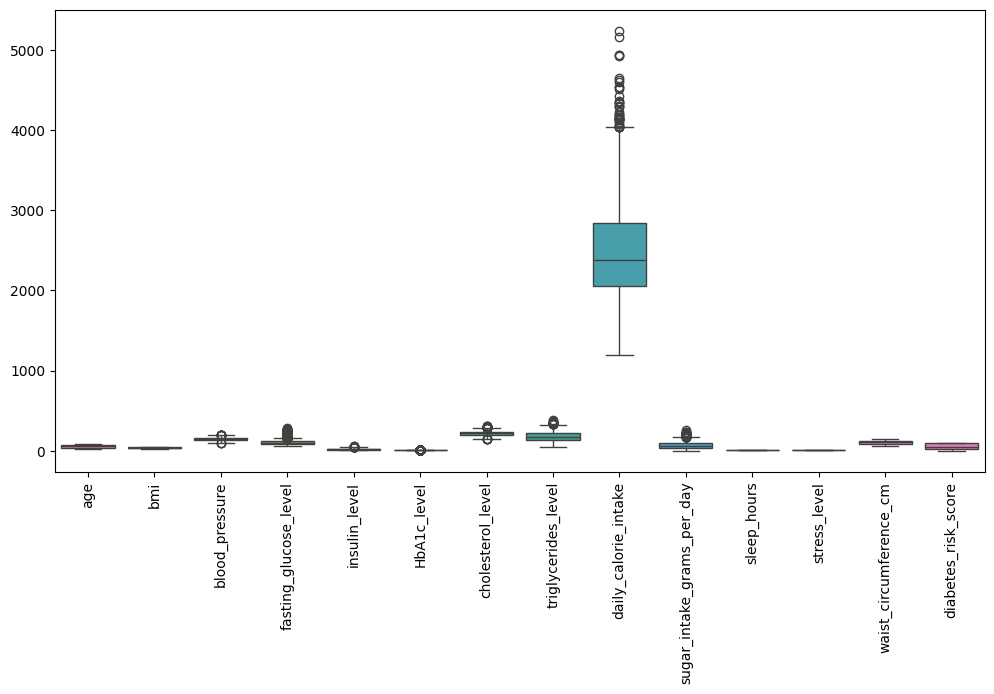

In [39]:
import seaborn as sns


plt.figure(figsize=(12,6)) # adjust size
sns.boxplot(data=df[numeric_cols]) # draw numeric columns
plt.xticks(rotation=90) # rotate lables
plt.show()

### Box Plot Analysis
We used box plots to visualize the distribution of all numerical features and to better understand the presence of outliers.

The plots show that some features, such as daily calorie intake, fasting glucose level, and HbA1c level, contain several outliers, as indicated by points outside the whiskers.

In contrast, other features such as age, sleep hours, and stress level show fewer outliers and a more consistent distribution.

These visualizations confirm the results obtained from the outlier detection step and help us better understand the variability in the dataset.

## e.3) handle outliers

In [40]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
    #delete if it is lower than lower bound or higher than higher bound

### Handling Outliers
After identifying and analyzing the outliers, we decided to remove them using the IQR method to improve the quality of the dataset.

Values that were below the lower bound or above the upper bound were removed, as they may negatively affect the performance of machine learning models.

This step helps reduce noise and ensures that the dataset becomes more reliable and suitable for further analysis.

## e.4) after delete

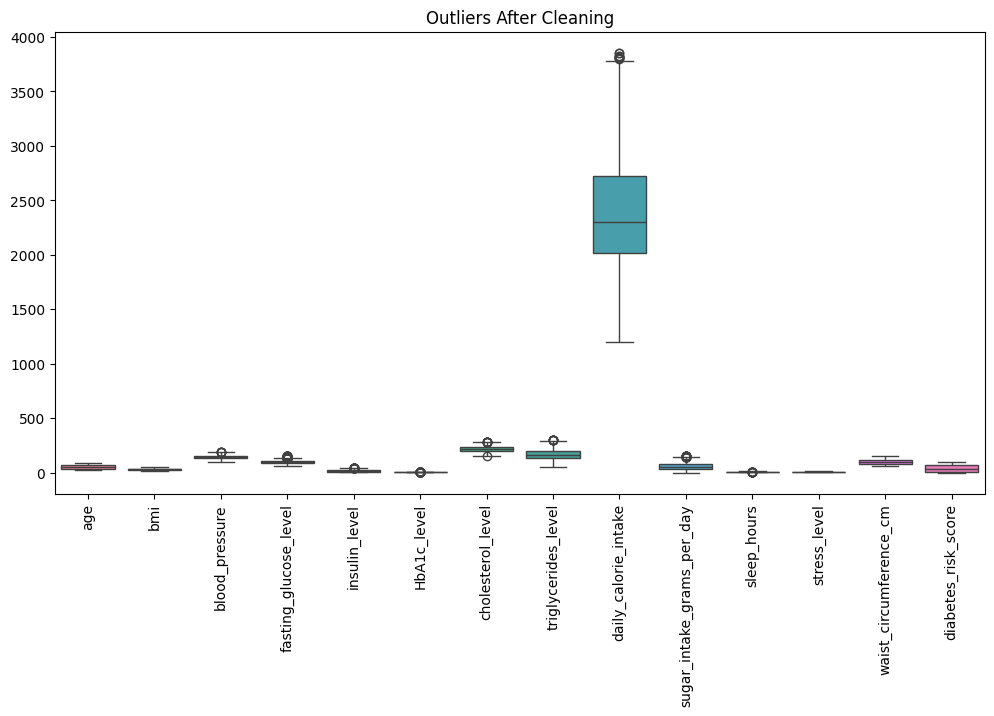

In [41]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Outliers After Cleaning")
plt.show()

### After Removing Outliers
After removing the outliers, we visualized the data again using box plots to evaluate the effect of the cleaning process.

The updated plots show a more compact and consistent distribution across most numerical features, with significantly fewer extreme values compared to before.

This indicates that the dataset has become cleaner and more suitable for analysis, which can help improve the performance of machine learning models.

# 5) Exploratory Data Analysis (EDA)

we explore the dataset through various visualization to understand the distribution of features and their relationship with the target variable(diabetes_risk_category)

### a.Visualization 1: Bar Chart(count Plot)

/tmp/ipykernel_598/1484036640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes_risk_category', data=df,palette='magma',order=['Low Risk' ,'Prediabetes' ,'High Risk'])


<function matplotlib.pyplot.show(close=None, block=None)>

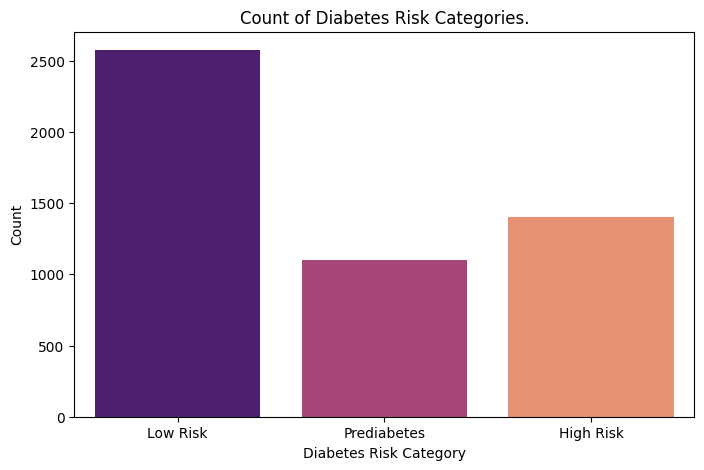

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
# set the dimensions of the figure
plt.figure(figsize=(8,5))
# creat a count plot to show the frequency
# using 'magme' color palette
sns.countplot(x='diabetes_risk_category', data=df,palette='magma',order=['Low Risk' ,'Prediabetes' ,'High Risk'])
# add a title to the chart with a fount size of 12
plt.title('Count of Diabetes Risk Categories.', fontsize = 12)
# nameing the x axis
plt.xlabel('Diabetes Risk Category')
# nameing the y axis
plt.ylabel('Count')
# display the plot
plt.show

### Distribution of Diabetes Risk Categories
In this visualization, we used a bar chart (count plot) to show the distribution of diabetes risk categories in the dataset.

The plot shows that the "Low Risk" category has the highest number of samples, followed by "High Risk", while "Prediabetes" has the lowest count.

This indicates that the dataset is slightly imbalanced, with more observations in the low-risk group compared to the other categories.

Understanding this distribution is important because class imbalance may affect the performance of machine learning models and should be considered during model training.

### b.Visualization 2 : Histogram

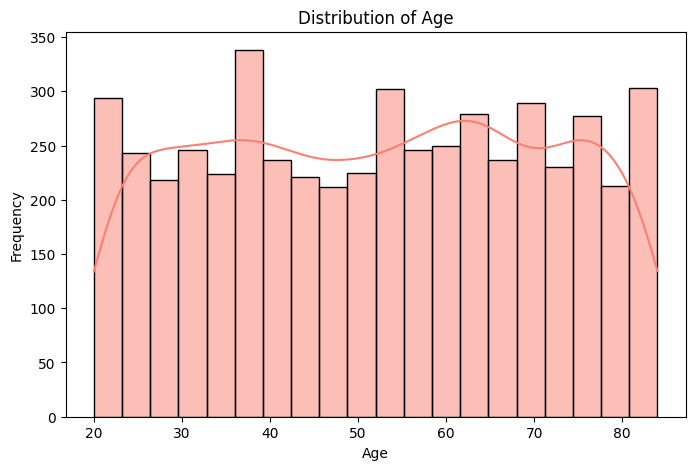

In [43]:
# set the dimensions of the figure
plt.figure(figsize=(8,5))
#plot the distribution of age with a KDE
sns.histplot(df['age'], bins=20, kde=True , color='Salmon')
# add a title to the Histogram with a fount 12
plt.title('Distribution of Age' , fontsize = 12)
# naming the x axis
plt.xlabel('Age')
# naming the y axis
plt.ylabel('Frequency')
# display the plot
plt.show()

### Distribution of Age
In this visualization, we used a histogram to analyze the distribution of the age feature in the dataset.

The histogram shows that age values are spread across a wide range, approximately from 20 to 80 years. The distribution appears relatively smooth without extreme peaks or heavy skewness.

This indicates that the age feature is fairly well distributed, which is useful for analysis and modeling as it provides diverse information across different age groups.

### c.Visualization 3 : Box plot

/tmp/ipykernel_598/447703798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diabetes_risk_category', y='fasting_glucose_level', data=df, palette='Set3',order=['Low Risk' ,'Prediabetes' ,'High Risk'])


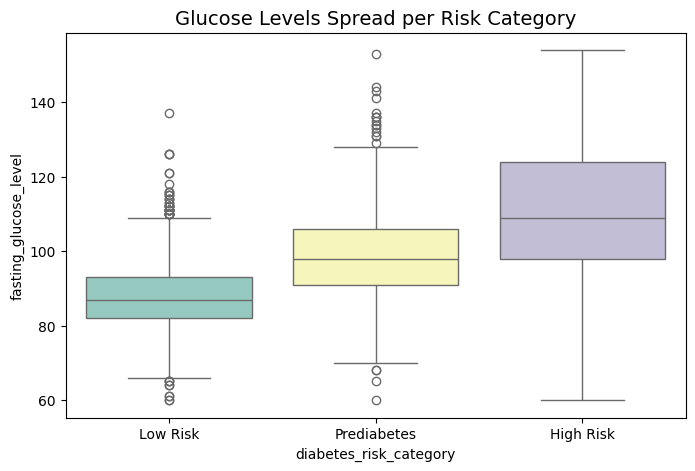

In [44]:
#set the dimensions of the figure
plt.figure(figsize=(8,5))
# Create a box plot
sns.boxplot(x='diabetes_risk_category', y='fasting_glucose_level', data=df, palette='Set3',order=['Low Risk' ,'Prediabetes' ,'High Risk'])
# add a title
plt.title('Glucose Levels Spread per Risk Category',fontsize=14)
# disply the plot
plt.show()

### Glucose Levels Across Risk Categories
In this visualization, we used a box plot to examine the distribution of fasting glucose levels across different diabetes risk categories.

The plot shows a clear increasing trend in glucose levels from "Low Risk" to "Prediabetes" and "High Risk". Individuals in the high-risk category tend to have higher glucose levels compared to the other groups.

This indicates a strong relationship between fasting glucose level and diabetes risk category, suggesting that glucose level is an important feature for predicting diabetes risk.

### d.Visualization 4 :Scatter Plot

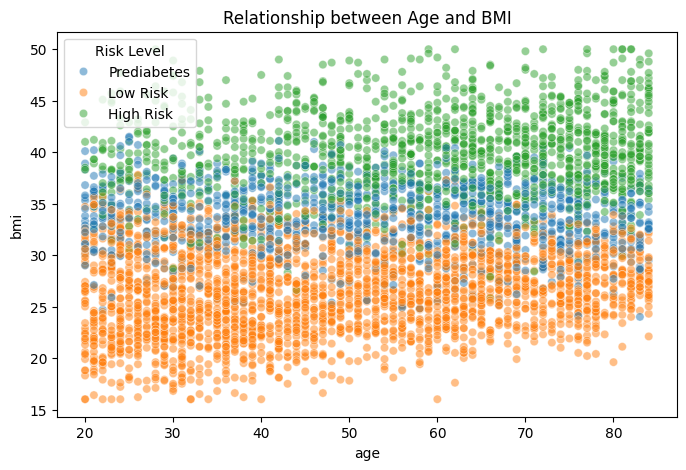

In [45]:
# set the figure size
plt.figure(figsize=(8,5))
# creat a scatter plot to visualize relationship between age and BMI
# 'hue' is used to differnentiate disabets risk categories by color
sns.scatterplot(x='age', y='bmi', hue='diabetes_risk_category',data=df,alpha=0.5)
# add a title and customize the lengend
plt.title("Relationship between Age and BMI" , fontsize=12)
plt.legend(title="Risk Level")
# diplay the plot
plt.show()

### Relationship between Age and BMI
In this visualization, we used a scatter plot to explore the relationship between age and BMI, while distinguishing diabetes risk categories using color.

The plot shows that individuals in the "High Risk" category tend to have higher BMI values compared to those in the "Low Risk" and "Prediabetes" categories.

Although age varies across all groups, BMI appears to have a stronger relationship with diabetes risk. Higher BMI values are more associated with higher risk levels.

This suggests that BMI is an important factor in predicting diabetes risk.

### e.Visualization 5 :Heatmap





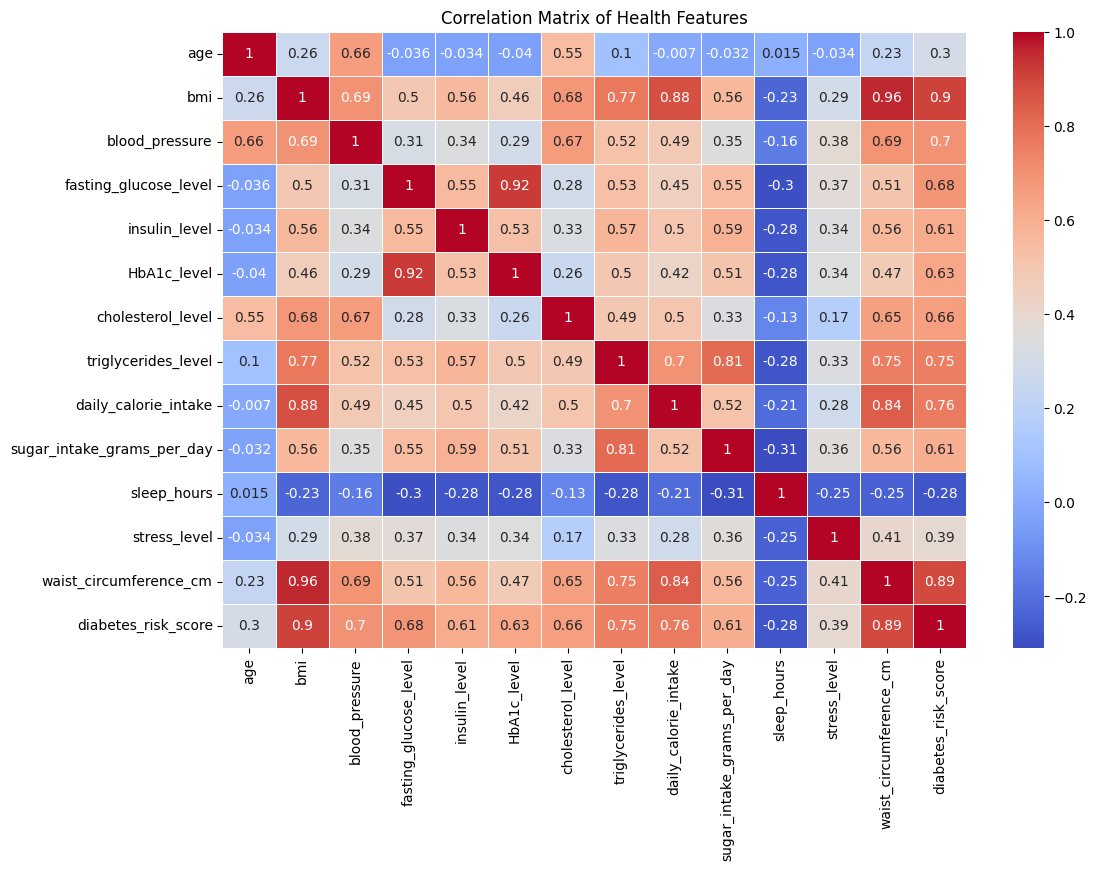

In [46]:
# set the plot size
plt.figure(figsize=(12,8))
# select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64','float64'])
# create the heatmap to show reletionships between features
# 'annot'= True shows the number inside the squares
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
# add a title to the plot and font
plt.title('Correlation Matrix of Health Features', fontsize=12)
# disply the plot
plt.show()

### Correlation Between Features
In this visualization, we used a heatmap to analyze the relationships between numerical features in the dataset.

The heatmap reveals several strong positive correlations. For instance, BMI is highly correlated with waist circumference, and both show a strong relationship with the diabetes risk score. This indicates that body composition measures are important indicators of diabetes risk.

Additionally, fasting glucose level shows a strong correlation with HbA1c level, which is expected as both are related to blood sugar levels.

We also observe that daily calorie intake and triglyceride levels are positively correlated, suggesting a relationship between diet and lipid levels.

On the other hand, sleep hours show negative correlations with several features, indicating that lower sleep duration may be associated with poorer health conditions.

Overall, the heatmap helps identify the most influential features and provides valuable insights into the relationships within the dataset.